# Lecture 07 Theory - Classification by Logistic Regression

Logistic regression is a single-layer linear classifier. It turns a linear
score into a probability, then learns by repeatedly reducing a loss:

prediction -> loss -> gradient -> weight update

Sigmoid gives a model-estimated prediction. Loss, gradients, and updates make the model
learn.


## Roadmap

1. From perceptron to probabilities
2. Sigmoid
3. Binary logistic regression
4. Cross-entropy
5. How weights are learned
6. Gradient descent training
7. Decision boundary and confidence
8. L2 regularization
9. Multi-class classification
10. One-vs-Rest
11. Softmax regression
12. Multi-class cross-entropy
13. Summary


In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(7)
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


def sigmoid(z):
    return 1 / (1 + np.exp(-z))


def binary_cross_entropy(y, p):
    eps = 1e-12
    p = np.clip(p, eps, 1 - eps)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))


def softmax(z, axis=-1):
    shifted = z - np.max(z, axis=axis, keepdims=True)
    exp_z = np.exp(shifted)
    return exp_z / exp_z.sum(axis=axis, keepdims=True)


def plot_boundary(ax, X, y, w, b, title):
    x0 = np.linspace(X[:, 0].min() - .8, X[:, 0].max() + .8, 240)
    x1 = np.linspace(X[:, 1].min() - .8, X[:, 1].max() + .8, 240)
    xx, yy = np.meshgrid(x0, x1)
    p = sigmoid(w[0] * xx + w[1] * yy + b)
    ax.contourf(xx, yy, p, levels=np.linspace(0, 1, 11), cmap="RdBu_r", alpha=.28)
    ax.contour(xx, yy, p, levels=[.5], colors="#263238", linewidths=2)
    ax.scatter(X[y == 0, 0], X[y == 0, 1], c="#3274a1", edgecolor="white", s=40, label="class 0")
    ax.scatter(X[y == 1, 0], X[y == 1, 1], c="#e1812c", edgecolor="white", s=40, label="class 1")
    ax.set(title=title, xlabel="feature 1", ylabel="feature 2")
    ax.legend(frameon=False, loc="upper left")


## 1. Connecting to Earlier Models

Every model below starts with a linear score. Logistic regression is not a
new architecture; its important change is replacing a hard step with a
probability-producing sigmoid.


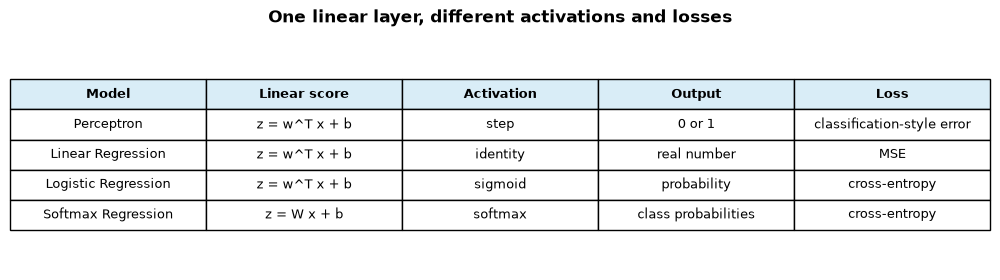

In [2]:
fig, ax = plt.subplots(figsize=(11, 3))
ax.axis("off")
labels = ["Model", "Linear score", "Activation", "Output", "Loss"]
rows = [
    ["Perceptron", "z = w^T x + b", "step", "0 or 1", "classification-style error"],
    ["Linear Regression", "z = w^T x + b", "identity", "real number", "MSE"],
    ["Logistic Regression", "z = w^T x + b", "sigmoid", "probability", "cross-entropy"],
    ["Softmax Regression", "z = W x + b", "softmax", "class probabilities", "cross-entropy"],
]
table = ax.table(cellText=rows, colLabels=labels, cellLoc="center", loc="center")
table.auto_set_font_size(False)
table.set_fontsize(9.5)
table.scale(1.15, 1.8)
for j in range(len(labels)):
    table[(0, j)].set_facecolor("#d9edf7")
    table[(0, j)].set_text_props(weight="bold")
ax.set_title("One linear layer, different activations and losses", weight="bold", pad=12)
plt.show()


## 2. From a Perceptron to Probabilities

A perceptron gives the same class for z=0.01 and z=100. Both are positive,
but their confidence should not be treated as identical.

Sigmoid maps any real score into (0, 1):

$$
p = sigmoid(z) = 1 / (1 + exp(-z))
$$

Large negative scores approach 0, zero maps to 0.5, and large positive
scores approach 1. In binary logistic regression, p is the predicted
probability of class 1.


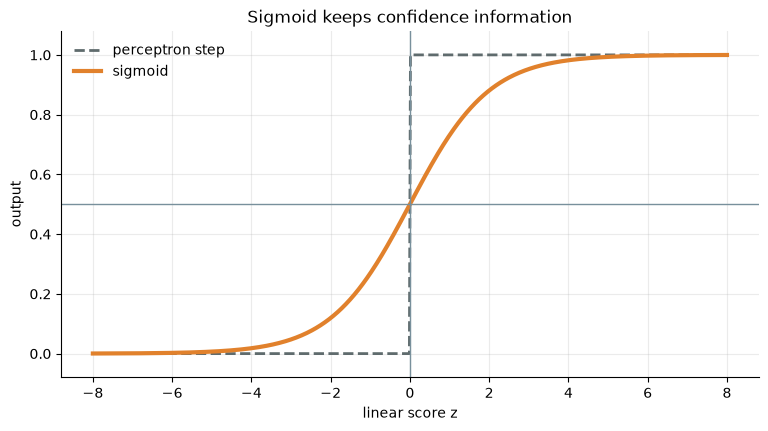

sigmoid(-5) = 0.0067
sigmoid(-2) = 0.1192
sigmoid( 0) = 0.5000
sigmoid( 2) = 0.8808
sigmoid( 5) = 0.9933


In [3]:
z_values = np.linspace(-8, 8, 600)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(z_values, (z_values >= 0).astype(int), "--", color="#5f6b6d", lw=2, label="perceptron step")
ax.plot(z_values, sigmoid(z_values), color="#e1812c", lw=3, label="sigmoid")
ax.axhline(.5, color="#78909c", lw=1)
ax.axvline(0, color="#78909c", lw=1)
ax.set(title="Sigmoid keeps confidence information", xlabel="linear score z", ylabel="output", ylim=(-.08, 1.08))
ax.legend(frameon=False)
plt.show()
for z in [-5, -2, 0, 2, 5]:
    print(f"sigmoid({z:>2}) = {sigmoid(z):.4f}")


Sigmoid does not make a nonlinear boundary. A threshold of 0.5 gives class
1 when z is at least zero, so the boundary remains:

$$
w^T x + b = 0
$$


## 3. One Manual Forward Pass

The forward path for one example is short: inputs create a weighted sum,
sigmoid converts it to a probability, and loss compares it with the target.


In [4]:
x_one = np.array([2.0, 1.0])
w_one = np.array([0.4, -0.2])
b_one = 0.1
y_one = 1.0
z_one = w_one @ x_one + b_one
p_one = sigmoid(z_one)
loss_one = binary_cross_entropy(np.array([y_one]), np.array([p_one]))
print(f"z = {z_one:.3f}")
print(f"p = {p_one:.3f}")
print(f"loss = {loss_one:.3f}")


z = 0.700
p = 0.668
loss = 0.403


## Why Not Just Count Wrong Classifications?

The 0/1 loss gives the same value to p=0.49 and p=0.01 when the true class is
1: both predictions are simply wrong. It also stays flat while a small weight
change leaves the hard class unchanged. That gives gradient descent almost no
useful direction.

Cross-entropy distinguishes these probabilities and provides a smooth objective
that can guide weight updates.


### Where Cross-Entropy Comes From

The model should assign high probability to labels that actually occurred in
the training data. Maximizing those observed-label probabilities is maximum
likelihood. Taking the negative logarithm turns that objective into the
cross-entropy loss that is minimized.


## 4. Cross-Entropy Measures a Probability

Binary cross-entropy for one example is:

$$
L(y,p) = -[y log(p) + (1-y) log(1-p)]
$$

If y=1, only -log(p) remains. If y=0, only -log(1-p) remains. A confident
wrong prediction receives a very large loss, creating a strong learning
signal.


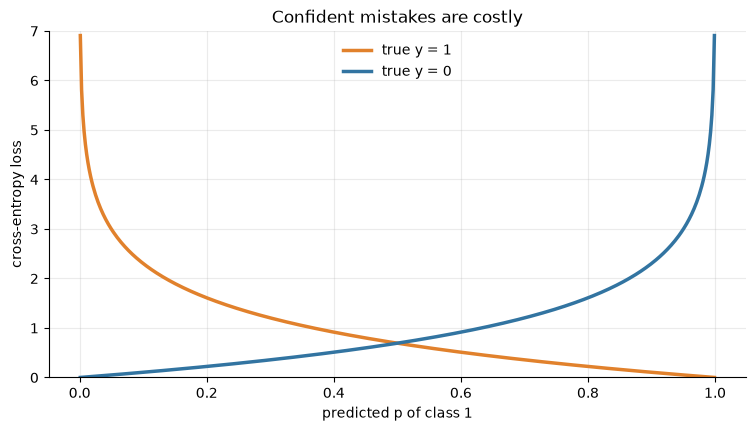

y=1, p= 0.99: loss=0.010
y=1, p=  0.9: loss=0.105
y=1, p=  0.6: loss=0.511
y=1, p=  0.1: loss=2.303
y=1, p=0.001: loss=6.908


In [5]:
p_grid = np.linspace(.001, .999, 500)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(p_grid, -np.log(p_grid), color="#e1812c", lw=2.5, label="true y = 1")
ax.plot(p_grid, -np.log(1 - p_grid), color="#3274a1", lw=2.5, label="true y = 0")
ax.set(title="Confident mistakes are costly", xlabel="predicted p of class 1", ylabel="cross-entropy loss", ylim=(0, 7))
ax.legend(frameon=False)
plt.show()
for p in [.99, .9, .6, .1, .001]:
    print(f"y=1, p={p:>5}: loss={-np.log(p):.3f}")


## 5. How Weights Learn

Weights do not change because sigmoid exists. Training repeats:

forward pass -> loss -> gradient -> update -> new forward pass

A derivative answers: if this parameter increases slightly, does loss rise
or fall, and by how much? Gradient descent uses:

$$
weight = weight - learning_rate * gradient
$$

The minus sign moves parameters downhill. A positive gradient is reduced;
a negative gradient is increased.


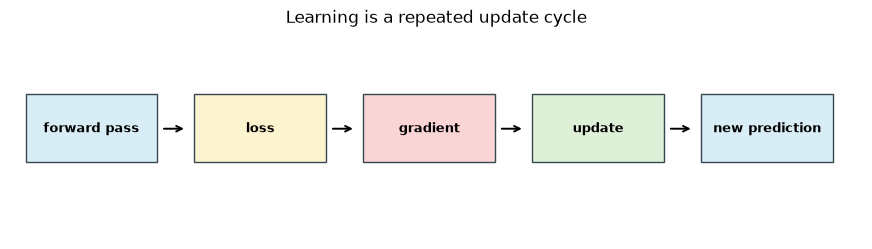

In [6]:
fig, ax = plt.subplots(figsize=(11, 2.7))
ax.axis("off")
stages = ["forward pass", "loss", "gradient", "update", "new prediction"]
colors = ["#d9edf7", "#fcf3cf", "#f9d6d5", "#dff0d8", "#d9edf7"]
for i, (stage, color) in enumerate(zip(stages, colors)):
    left = .2 + i * 2.18
    ax.add_patch(plt.Rectangle((left, .85), 1.7, .75, facecolor=color, edgecolor="#37474f"))
    ax.text(left + .85, 1.22, stage, ha="center", va="center", weight="bold", fontsize=9)
    if i < 4:
        ax.annotate("", xy=(left + 2.08, 1.22), xytext=(left + 1.75, 1.22), arrowprops={"arrowstyle": "->", "lw": 1.4})
ax.set(xlim=(0, 11), ylim=(0, 2.3), title="Learning is a repeated update cycle")
plt.show()


### The Key Gradient

For z = w^T x + b, p = sigmoid(z), and binary cross-entropy:

$$
dL/dz = p-y
$$

This error signal contains direction and size. If y=1 and p=0.2, it is
-0.8, so the score should increase. If y=0 and p=0.9, it is +0.9, so the
score should decrease.

Each feature scales its own weight gradient:

$$
dL/dw_i = (p-y)x_i,  dL/db = p-y
$$


In [7]:
error_signal = -.8
x_gradient = np.array([2.0, .1])
print("error p-y:", error_signal)
print("inputs:", x_gradient)
print("weight gradients:", error_signal * x_gradient)
print("The larger input produces the larger weight update.")


error p-y: -0.8
inputs: [2.  0.1]
weight gradients: [-1.6  -0.08]
The larger input produces the larger weight update.


## 6. One Complete Manual Update

This example uses one target with y=1. The same example is evaluated before
and after one gradient descent update.


In [8]:
x_manual = np.array([2.0, 1.0])
y_manual = 1.0
w_manual = np.array([.1, -.2])
b_manual = 0.0
lr_manual = .1

p_old = sigmoid(w_manual @ x_manual + b_manual)
loss_old = binary_cross_entropy(np.array([y_manual]), np.array([p_old]))
error_manual = p_old - y_manual
dw_manual = error_manual * x_manual
db_manual = error_manual
w_new = w_manual - lr_manual * dw_manual
b_new = b_manual - lr_manual * db_manual
p_new = sigmoid(w_new @ x_manual + b_new)
loss_new = binary_cross_entropy(np.array([y_manual]), np.array([p_new]))

delta_w_manual = -lr_manual * dw_manual
delta_b_manual = -lr_manual * db_manual
print("old weights:", w_manual, "old bias:", b_manual)
print("gradient:", np.round(dw_manual, 3), "db:", round(db_manual, 3))
print("change:", np.round(delta_w_manual, 3), "delta_b:", round(delta_b_manual, 3))
print("new weights:", np.round(w_new, 3), "new bias:", round(b_new, 3))
print(f"old probability/loss: {p_old:.3f} / {loss_old:.3f}")
print(f"new probability/loss: {p_new:.3f} / {loss_new:.3f}")


old weights: [ 0.1 -0.2] old bias: 0.0
gradient: [-1.  -0.5] db: -0.5
change: [0.1  0.05] delta_b: 0.05
new weights: [ 0.2  -0.15] new bias: 0.05
old probability/loss: 0.500 / 0.693
new probability/loss: 0.574 / 0.554


## 7. Dataset Form and Gradient Descent

For N examples, rows of X contain inputs:

$$
z = Xw+b,  p=sigmoid(z),  error=p-y
$$

Batch gradients average contributions from all examples:

$$
dw = X^T error / N,  db = mean(error)
$$


In [9]:
def train_logistic_regression(X, y, learning_rate=.1, epochs=500, lambda_=0.0):
    n_samples, n_features = X.shape
    w = np.zeros(n_features)
    b = 0.0
    history = []

    for _ in range(epochs):
        z = X @ w + b
        p = sigmoid(z)
        data_loss = binary_cross_entropy(y, p)
        history.append(data_loss + lambda_ * np.sum(w ** 2))

        error = p - y
        dw = X.T @ error / n_samples
        dw += 2 * lambda_ * w
        db = np.mean(error)

        w -= learning_rate * dw
        b -= learning_rate * db

    return w, b, np.array(history)


The function above is the learning algorithm. The forward pass makes p; the
error, gradients, and updates make the parameters change. No hidden layer,
automatic differentiation, or library estimator is involved.


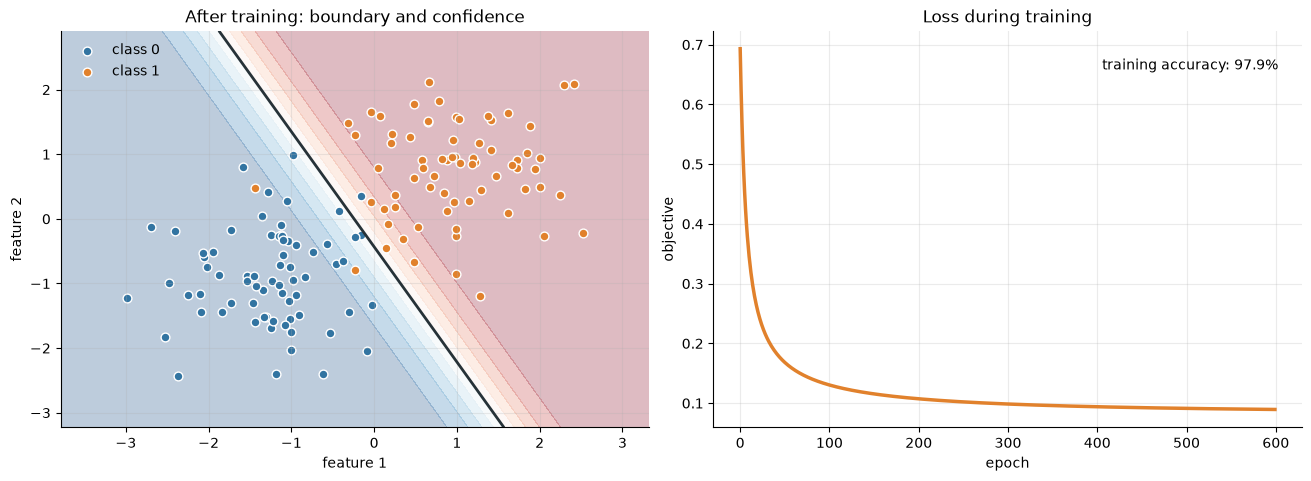

w: [3.198 1.794] b: 0.775


In [10]:
X0 = rng.normal([-1.1, -.8], [.75, .8], size=(70, 2))
X1 = rng.normal([1.0, .9], [.75, .8], size=(70, 2))
X_binary = np.vstack([X0, X1])
y_binary = np.r_[np.zeros(70), np.ones(70)]

w_fit, b_fit, history_fit = train_logistic_regression(X_binary, y_binary, learning_rate=.15, epochs=600)
p_fit = sigmoid(X_binary @ w_fit + b_fit)
training_accuracy = np.mean((p_fit >= .5) == y_binary)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.7), constrained_layout=True)
plot_boundary(axes[0], X_binary, y_binary, w_fit, b_fit, "After training: boundary and confidence")
axes[1].plot(history_fit, color="#e1812c", lw=2.5)
axes[1].set(title="Loss during training", xlabel="epoch", ylabel="objective")
axes[1].text(.96, .93, f"training accuracy: {training_accuracy:.1%}", transform=axes[1].transAxes, ha="right", va="top")
plt.show()
print("w:", np.round(w_fit, 3), "b:", round(b_fit, 3))


The p=0.5 contour is a straight line even though probability changes
smoothly across the plane. Logistic regression is therefore a linear
classifier with confidence information.


## 8. L2 Regularization

L2 regularization adds a penalty:

$$
total loss = cross-entropy + lambda * sum(w^2)
$$

It discourages extreme weights and can reduce overfitting. The added
gradient is 2 * lambda * w, so the normal data gradient is combined with
pressure toward smaller weights. The bias is not regularized here.


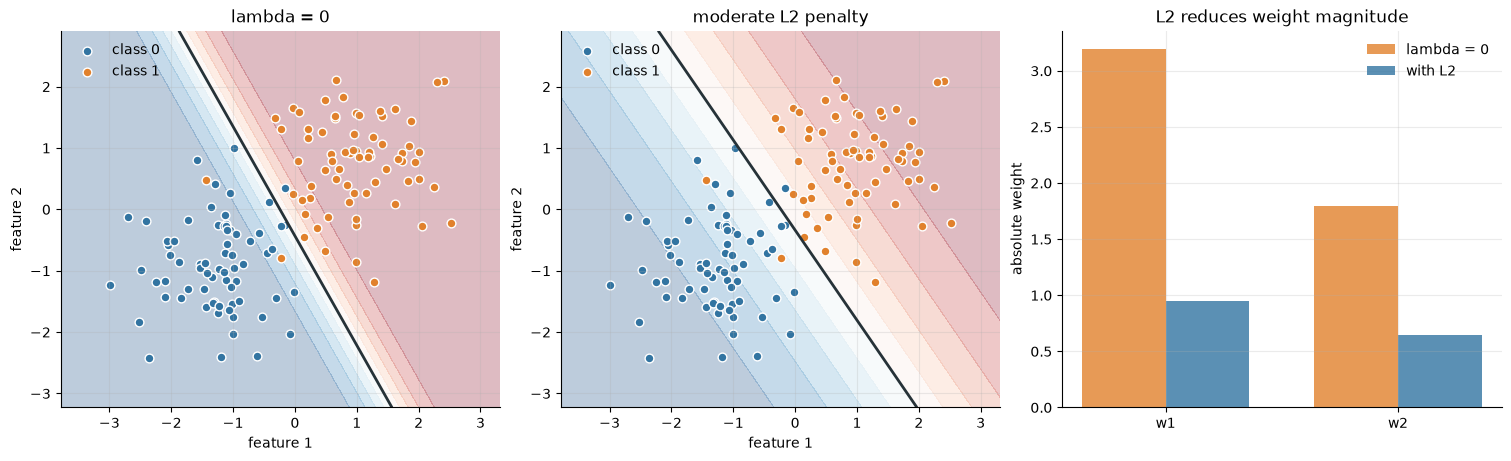

In [11]:
w_plain, b_plain, _ = train_logistic_regression(X_binary, y_binary, learning_rate=.15, epochs=600, lambda_=0)
w_l2, b_l2, _ = train_logistic_regression(X_binary, y_binary, learning_rate=.15, epochs=600, lambda_=.08)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)
plot_boundary(axes[0], X_binary, y_binary, w_plain, b_plain, "lambda = 0")
plot_boundary(axes[1], X_binary, y_binary, w_l2, b_l2, "moderate L2 penalty")
positions = np.arange(2)
axes[2].bar(positions - .18, np.abs(w_plain), width=.36, color="#e1812c", alpha=.8, label="lambda = 0")
axes[2].bar(positions + .18, np.abs(w_l2), width=.36, color="#3274a1", alpha=.8, label="with L2")
axes[2].set(title="L2 reduces weight magnitude", ylabel="absolute weight", xticks=positions, xticklabels=["w1", "w2"])
axes[2].legend(frameon=False)
plt.show()


## 9. Multi-Class Classification

Multi-class classification chooses exactly one class from K greater than 2.
Integer class IDs are fine as labels, but treating them as numeric regression targets would incorrectly introduce an ordering. Class indices are fine as labels; one-hot targets make the model output structure explicit:

cat: [1, 0, 0]
dog: [0, 1, 0]
horse: [0, 0, 1]

Multi-label classification is different: several independent labels may be
true, such as [dog, outdoor, snow].


## 10. One-vs-Rest

One-vs-Rest trains K binary classifiers. Classifier k predicts class k
against every other class, and the largest score or probability is chosen.

Softmax regression instead models K classes jointly, producing a single
probability distribution whose entries add to one.


## 11. Softmax Regression

For K logits, softmax gives:

$$
p_j = exp(z_j) / sum_k exp(z_k)
$$

Subtracting the maximum logit is a numerical-stability step. It does not
change the final probabilities.


probabilities: [0.6652 0.2447 0.09  ]
sum: 1.0
predicted index: 0


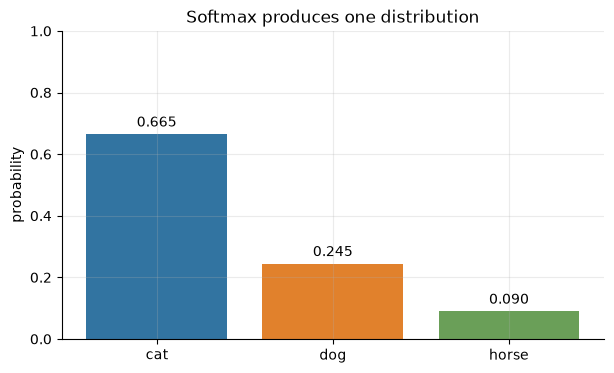

In [12]:
logits = np.array([2.0, 1.0, 0.0])
p_softmax = softmax(logits)
print("probabilities:", np.round(p_softmax, 4))
print("sum:", round(p_softmax.sum(), 6))
print("predicted index:", int(np.argmax(p_softmax)))
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(["cat", "dog", "horse"], p_softmax, color=["#3274a1", "#e1812c", "#6a9f58"])
ax.bar_label(bars, fmt="%.3f", padding=3)
ax.set(title="Softmax produces one distribution", ylabel="probability", ylim=(0, 1))
plt.show()


## 12. Multi-Class Cross-Entropy and Gradient

With a one-hot target t, multi-class cross-entropy is:

$$
L = -sum_j t_j log(p_j)
$$

Only the probability of the true class remains. Softmax regression has the
same central gradient pattern as the binary model:

$$
dL/dw_ji = (p_j - t_j) x_i
$$

The true class has target 1 and is pushed up when needed. Competing classes
have target 0 and are pushed down. W has shape K by D: one row per class.

Unlike the multi-class perceptron, softmax cross-entropy usually updates every class row because every class receives a probability and therefore contributes to the error.


In [13]:
x_multi = np.array([1.4, -.5])
W_multi = np.zeros((3, 2))
b_multi = np.zeros(3)
target_dog = np.array([0, 1, 0])
learning_rate_multi = 0.1

logits_before = W_multi @ x_multi + b_multi
p_before = softmax(logits_before)
error_multi = p_before - target_dog
dW_multi = np.outer(error_multi, x_multi)
db_multi = error_multi

W_new = W_multi - learning_rate_multi * dW_multi
b_new_multi = b_multi - learning_rate_multi * db_multi
p_after = softmax(W_new @ x_multi + b_new_multi)

print("before:", np.round(p_before, 3))
print("gradient rows:")
print(np.round(dW_multi, 3))
print("after: ", np.round(p_after, 3))
print("the dog probability increases after one update")


before: [0.333 0.333 0.333]
gradient rows:
[[ 0.467 -0.167]
 [-0.933  0.333]
 [ 0.467 -0.167]]
after:  [0.296 0.408 0.296]
the dog probability increases after one update


## 13. Backpropagation Comes Later

The derivatives here use the same chain-rule idea that later appears in
backpropagation. This model still has only one linear layer:

x -> linear layer -> sigmoid or softmax -> loss

There are no hidden layers, so this is not full neural-network
backpropagation.


## Summary

1. Logistic regression is a linear model with z = w^T x + b.
2. Sigmoid turns z into the model's estimated probability of class 1.
3. Cross-entropy measures the quality of that probability.
4. Learning requires loss, gradients, and repeated weight updates.
5. Binary gradients use (prediction - target) times input.
6. L2 regularization adds pressure toward smaller weights.
7. Softmax extends the same idea to mutually exclusive classes.
8. No hidden layers or full neural-network backpropagation appear yet.
